In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest


from utils import calc_mean_var, gaussian_probability

In [40]:
data = pd.read_csv('servers_data.csv')

x = data.values

print(x.shape)
print(data.head())
print(data.tail())

(23, 4)
   cpu_usage  memory_usage  disk_usage  network_traffic
0         22            45          52              120
1         25            48          50              130
2         21            43          55              115
3         24            46          51              125
4         23            44          53              118
    cpu_usage  memory_usage  disk_usage  network_traffic
18         24            45          51              123
19         26            46          52              130
20         95            98          90              950
21         92            96          91              870
22         88            94          89              800


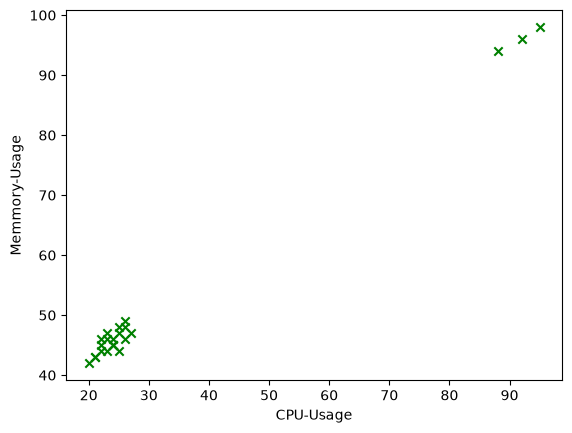

In [41]:
plt.scatter(data['cpu_usage'], data['memory_usage'], c='green', marker='x')
plt.xlabel('CPU-Usage')
plt.ylabel('Memmory-Usage')
plt.show()

(array([5., 8., 6., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([110. , 118.4, 126.8, 135.2, 143.6, 152. , 160.4, 168.8, 177.2,
        185.6, 194. , 202.4, 210.8, 219.2, 227.6, 236. , 244.4, 252.8,
        261.2, 269.6, 278. , 286.4, 294.8, 303.2, 311.6, 320. , 328.4,
        336.8, 345.2, 353.6, 362. , 370.4, 378.8, 387.2, 395.6, 404. ,
        412.4, 420.8, 429.2, 437.6, 446. , 454.4, 462.8, 471.2, 479.6,
        488. , 496.4, 504.8, 513.2, 521.6, 530. , 538.4, 546.8, 555.2,
        563.6, 572. , 580.4, 588.8, 597.2, 605.6, 614. , 622.4, 630.8,
        639.2, 647.6, 656. , 664.4, 672.8, 681.2, 689

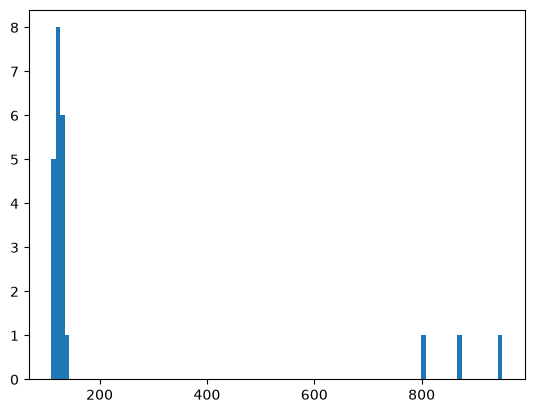

In [42]:
#? Checking if Data is A Gaussian distribution
plt.hist(data['network_traffic'], bins=100)

In [43]:
rows, cols = x.shape

mu, sigma2 = calc_mean_var(x, cols)
print(mu, '\n', sigma2)

[np.float64(32.52173913043478), np.float64(52.08695652173913), np.float64(56.95652173913044), np.float64(221.3913043478261)] 
 [np.float64(528.8582230623819), np.float64(292.4272211720227), np.float64(165.78071833648391), np.float64(64289.020793950855)]


In [ ]:


x_train = x[:20, :]

gaussian = gaussian_probability(x_train, mu, sigma2)
print(gaussian[0].shape)

(20,)


In [56]:
gaussian_prods = []

for i in range(len(gaussian)):
    gaussian_prods.append(np.prod(gaussian[i]))
    
gaussian_prods

[np.float64(1.2867638050508142e-36),
 np.float64(4.6279132723345e-34),
 np.float64(1.3232602520478772e-31),
 np.float64(1.9378571087755906e-57)]

In [73]:
epsilon = 0.00000000000000000000000000000000001

for i in gaussian_prods:
    
    anomaly = i < epsilon
    

    print(anomaly)


True
False
False
True
